In [2]:
import h5py
import requests
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
key = "api_key.txt"

with open(key) as file :
    api_key = file.read()


In [4]:
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":f"{api_key}"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [5]:
data = np.load("illustris3_z0_positions.npz")
pos = np.column_stack([data["x_pos"], data["y_pos"], data["z_pos"]])
print("loaded", len(pos), "subhalos")

loaded 121209 subhalos


In [6]:
np.random.seed(42)

n_data = 1000
idx = np.random.choice(len(pos), size=min(n_data, len(pos)), replace=False)
data_points = pos[idx]

boxsize = 75000   # Illustris box = 75 Mpc/h = 75000 ckpc/h
n_random = 3 * len(data_points)
random_points = np.random.rand(n_random, 3) * boxsize

#need to have same dimensionality in y and z
bins = np.linspace(0.1, 1, 100) * boxsize

def count_pairs(points1, points2, bins):
    pair_counts = np.zeros(len(bins) - 1)
    
    for i in range(len(points1)):
        distances_sq = np.sum((points1[i] - points2) ** 2, axis=1)
        counts, _ = np.histogram(np.sqrt(distances_sq), bins = bins)
        pair_counts += counts

    return pair_counts
        
dd = count_pairs(data_points, data_points, bins)
dr = count_pairs(data_points, random_points, bins)
rr = count_pairs(random_points, random_points, bins)


#get the num of points in each catalog
nD = len(data_points)
nR = len(random_points)

dd = dd / (nD * (nD - 1)/2)
dr = dr / (nD * nR)
rr = rr / (nR * (nR - 1)/2)

In [7]:
xi_all = []
n_repeat = 30

for k in range(n_repeat):
    idx = np.random.choice(len(pos), size=n_data, replace=False)
    data_points = pos[idx]
    nD = len(data_points)

    dd = count_pairs(data_points, data_points,   bins)
    dr = count_pairs(data_points, random_points, bins)
    dd = dd / (nD * (nD - 1)/2)
    dr = dr / (nD * nR)

    # COMPUTE THE 2PCF USING LANDY-SZALAY ESTIMATOR
    xi = np.zeros_like(dd, dtype=float)
    valid_bins = rr != 0
    xi[valid_bins] = (dd[valid_bins] - 2 * dr[valid_bins] + rr[valid_bins]) / rr[valid_bins]
    xi[~valid_bins] = np.nan
    xi_all.append(xi)

xi_all = np.array(xi_all)          # shape (n_repeat, n_bins)

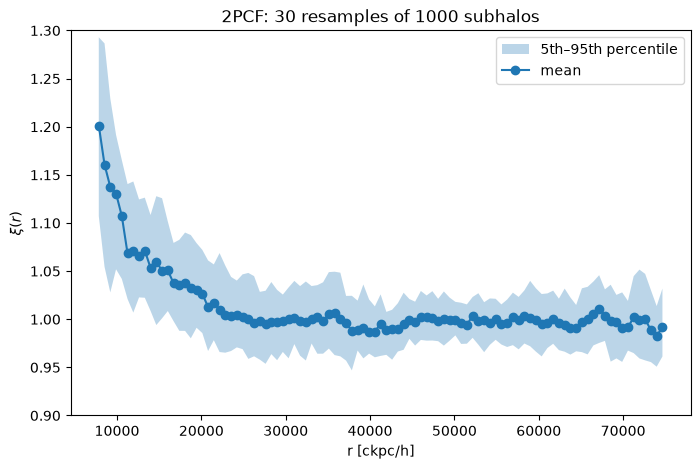

In [8]:
centers = 0.5 * (bins[:-1] + bins[1:])

xi_mean = np.nanmean(xi_all, axis=0)
xi_lo   = np.nanpercentile(xi_all, 5,  axis=0)
xi_hi   = np.nanpercentile(xi_all, 95, axis=0)

plt.figure(figsize=(8, 5))
plt.fill_between(centers, xi_lo, xi_hi, alpha=0.3, label="5th–95th percentile")
plt.plot(centers, xi_mean, "o-", label="mean")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.ylim(0.9, 1.3) 
plt.xlabel("r [ckpc/h]")
plt.ylabel(r"$\xi(r)$")
plt.title(f"2PCF: {n_repeat} resamples of {n_data} subhalos")
plt.legend()
plt.show()

In [9]:
#try another version with 10000 subhalos, confirm that increasing subhalo concentration doesnt affect 2pcf
#need some sort of machine vision to classify voids

In [10]:
np.random.seed(42)

n_data = 10000
idx = np.random.choice(len(pos), size=min(n_data, len(pos)), replace=False)
data_points = pos[idx]

boxsize = 75000   # Illustris box = 75 Mpc/h = 75000 ckpc/h
n_random = 3 * len(data_points)
random_points = np.random.rand(n_random, 3) * boxsize

#need to have same dimensionality in y and z
bins = np.linspace(0.1, 1, 100) * boxsize

def count_pairs(points1, points2, bins):
    pair_counts = np.zeros(len(bins) - 1)
    
    for i in range(len(points1)):
        distances_sq = np.sum((points1[i] - points2) ** 2, axis=1)
        counts, _ = np.histogram(np.sqrt(distances_sq), bins = bins)
        pair_counts += counts

    return pair_counts
        
dd = count_pairs(data_points, data_points, bins)
dr = count_pairs(data_points, random_points, bins)
rr = count_pairs(random_points, random_points, bins)


#get the num of points in each catalog
nD = len(data_points)
nR = len(random_points)

dd = dd / (nD * (nD - 1)/2)
dr = dr / (nD * nR)
rr = rr / (nR * (nR - 1)/2)

In [11]:
xi_all = []
n_repeat = 30

for k in range(n_repeat):
    idx = np.random.choice(len(pos), size=n_data, replace=False)
    data_points = pos[idx]
    nD = len(data_points)

    dd = count_pairs(data_points, data_points,   bins)
    dr = count_pairs(data_points, random_points, bins)
    dd = dd / (nD * (nD - 1)/2)
    dr = dr / (nD * nR)

    # COMPUTE THE 2PCF USING LANDY-SZALAY ESTIMATOR
    xi = np.zeros_like(dd, dtype=float)
    valid_bins = rr != 0
    xi[valid_bins] = (dd[valid_bins] - 2 * dr[valid_bins] + rr[valid_bins]) / rr[valid_bins]
    xi[~valid_bins] = np.nan
    xi_all.append(xi)

xi_all = np.array(xi_all)          # shape (n_repeat, n_bins)

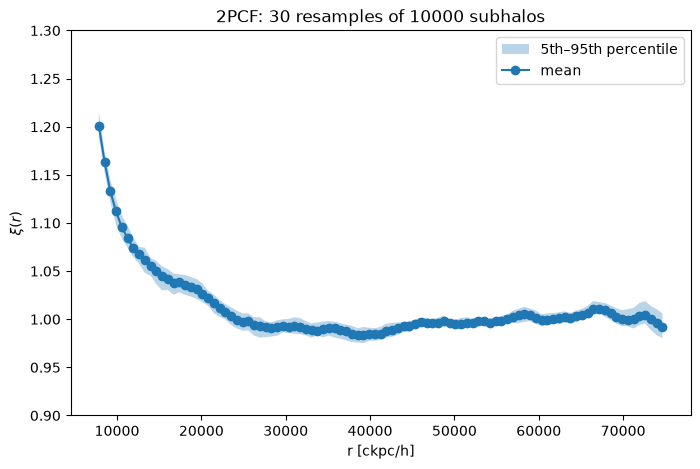

In [12]:
centers = 0.5 * (bins[:-1] + bins[1:])

xi_mean = np.nanmean(xi_all, axis=0)
xi_lo   = np.nanpercentile(xi_all, 5,  axis=0)
xi_hi   = np.nanpercentile(xi_all, 95, axis=0)

plt.figure(figsize=(8, 5))
plt.fill_between(centers, xi_lo, xi_hi, alpha=0.3, label="5th–95th percentile")
plt.plot(centers, xi_mean, "o-", label="mean")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.ylim(0.9, 1.3) 
plt.xlabel("r [ckpc/h]")
plt.ylabel(r"$\xi(r)$")
plt.title(f"2PCF: {n_repeat} resamples of {n_data} subhalos")
plt.legend()
plt.show()